Steps:

1. Clone the github repo
2. Download the dependencies and dataset
3. Run the EDA code block
4. Run the classification code block
5. Do not run the train code block. The model weight is already saved in github, /content/skin-lesion-classifier/models/efficientnetb4-v2/efficientnet_b4_v3_epoch_15.pth



In [1]:
#for cloning the github
!git clone -b init-skin-lesion-intsys https://github.com/venz-ochoa/skin-lesion-classifier.git
%cd skin-lesion-classifier

#we move to the initial branch first
!git checkout init-skin-lesion-intsys

Cloning into 'skin-lesion-classifier'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 115 (delta 2), reused 13 (delta 1), pack-reused 99 (from 2)
Receiving objects: 100% (115/115), 565.09 MiB | 22.06 MiB/s, done.
Resolving deltas: 100% (34/34), done.
Filtering content: 100% (2/2), 135.37 MiB | 15.45 MiB/s, done.
/content/skin-lesion-classifier
Already on 'init-skin-lesion-intsys'
Your branch is up to date with 'origin/init-skin-lesion-intsys'.


In [2]:
#to download the dependencies and datasets
!python /content/skin-lesion-classifier/source/download_data.py

cSkin Lesion Project Terminal
	[1] Download Dependencies
	[2] Download Datasets
	[3] Download Dependencies & Datasets

Enter: 3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:26<00:00, 210MB/s]

Downloaded HAM10000 Successfully!


---- HAM10000 Summary ----
Total Images: 10015

Class Counts:
cell_type
Nevus                   6705
Melanoma                1113
Benign Keratosis        1099
Basal Cell Carcinoma     514
Actinic Keratoses        327
Vascular Lesions         142
Dermatofibroma           115
Name: count, dtype: int64

Top 5 Localization Sites:
localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
Name: count, dtype: int64
------------------------



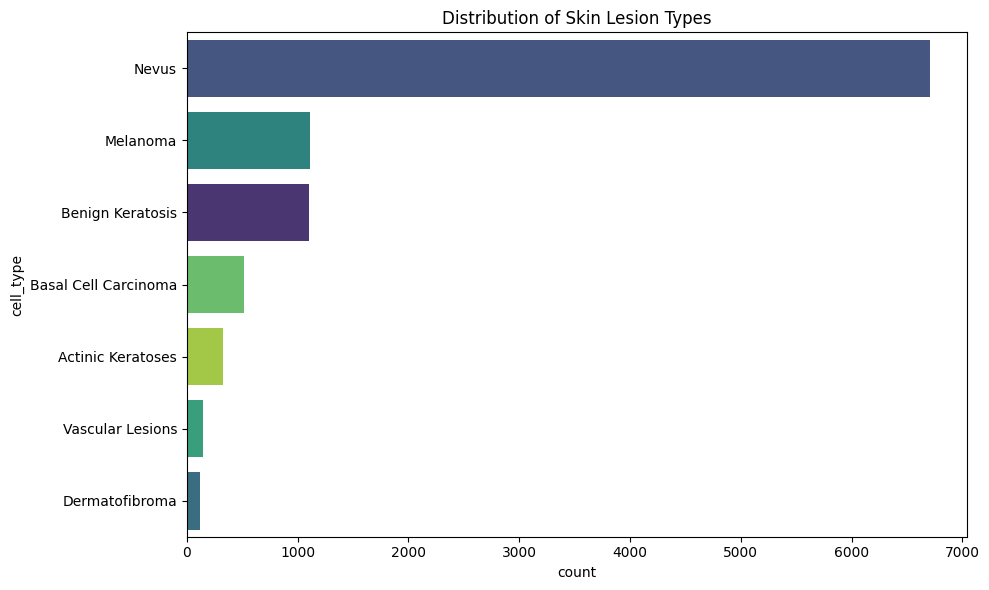

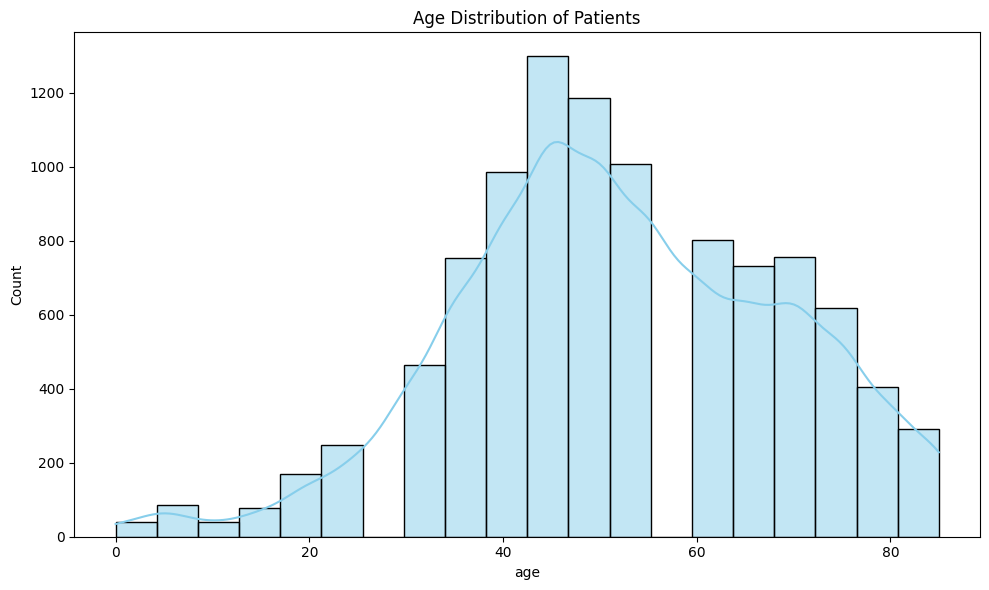

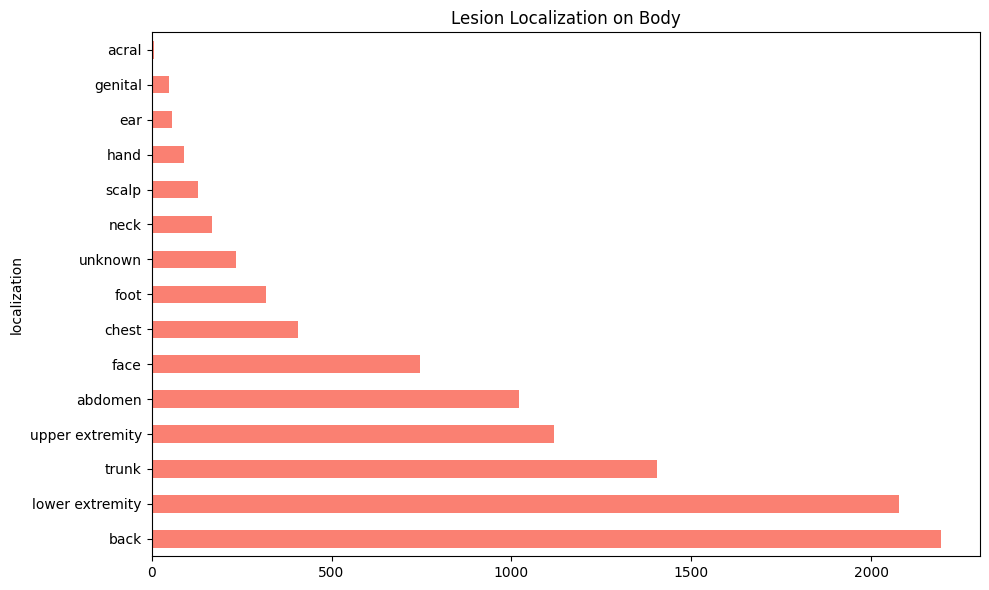

In [3]:
#exploratory data analysis
#distribution and information about HAM10000
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('/content/skin-lesion-classifier/EDA', exist_ok=True)
metadata = '/content/skin-lesion-classifier/data/ham10000/HAM10000_metadata.csv'
df = pd.read_csv(metadata)

labels = {
    'nv': 'Nevus',
    'mel': 'Melanoma',
    'bkl': 'Benign Keratosis',
    'bcc': 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratoses',
    'vasc': 'Vascular Lesions',
    'df': 'Dermatofibroma'
}
df['cell_type'] = df['dx'].map(labels)

#summary
print("---- HAM10000 Summary ----")
print(f"Total Images: {len(df)}")
print("\nClass Counts:")
print(df['cell_type'].value_counts())
print("\nTop 5 Localization Sites:")
print(df['localization'].value_counts().head(5))
print("------------------------\n")

# class distribution
plt.figure(figsize=(10,6))
sns.countplot(y='cell_type', data=df, order=df['cell_type'].value_counts().index, hue='cell_type', palette='viridis', legend=False)
plt.title('Distribution of Skin Lesion Types')
#so image doesnt clip/overlap with other elements and borders
plt.tight_layout()
plt.savefig('/content/skin-lesion-classifier/EDA/class_distribution.png')
plt.show()

# age distribution
plt.figure(figsize=(10,6))
sns.histplot(df['age'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Age Distribution of Patients')
plt.tight_layout()
plt.savefig('/content/skin-lesion-classifier/EDA/age_distribution.png')
plt.show()

# skin lesion localization distribution
plt.figure(figsize=(10,6))
df['localization'].value_counts().plot(kind='barh', color='salmon')
plt.title('Lesion Localization on Body')
plt.tight_layout()
plt.savefig('/content/skin-lesion-classifier/EDA/localization.png')
plt.show()

In [4]:
#classify diagnosis into malignant or benign. sorting the dataset into train, val, and test
!python /content/skin-lesion-classifier/source/classify_data.py

Benign is 0, Malignant is 1
binary_label
0    8061
1    1954
Name: count, dtype: int64

Sorting train data...
Sorting validation data...
Sorting test data...

Train size: 8012
Validation size: 1001
Test size: 1002


Augmentation sample saved as 'augmentation_samples.png'
Starting Training for 30 Epochs...
Epoch [1/30] - Train Loss: 0.5528 | Val Loss: 0.5820 | Val Acc: 0.7133 | Val F1: 0.5408 | Recall: 0.8667 | Prec: 0.3930
Epoch [2/30] - Train Loss: 0.3996 | Val Loss: 0.4716 | Val Acc: 0.7622 | Val F1: 0.5952 | Recall: 0.8974 | Prec: 0.4453
Epoch [3/30] - Train Loss: 0.3524 | Val Loss: 0.3744 | Val Acc: 0.8082 | Val F1: 0.6322 | Recall: 0.8462 | Prec: 0.5046
Epoch [4/30] - Train Loss: 0.3134 | Val Loss: 0.3560 | Val Acc: 0.8182 | Val F1: 0.6579 | Recall: 0.8974 | Prec: 0.5193
Epoch [5/30] - Train Loss: 0.2780 | Val Loss: 0.3303 | Val Acc: 0.8412 | Val F1: 0.6801 | Recall: 0.8667 | Prec: 0.5596
Epoch [6/30] - Train Loss: 0.2573 | Val Loss: 0.3182 | Val Acc: 0.8541 | Val F1: 0.6826 | Recall: 0.8051 | Prec: 0.5925
Epoch [7/30] - Train Loss: 0.2398 | Val Loss: 0.3777 | Val Acc: 0.8362 | Val F1: 0.6707 | Recall: 0.8564 | Prec: 0.5512
Epoch [8/30] - Train Loss: 0.2122 | Val Loss: 0.3173 | Val Acc: 0.870

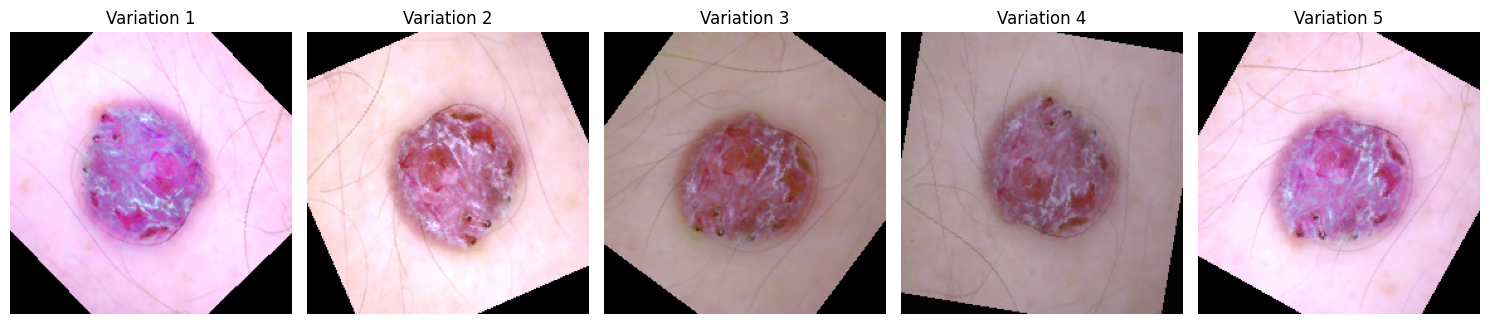

In [ ]:
#if you are getting errors, run the gitclone (first code block) and only run this code block
#efficientnet-v2 (AdamW + Square Root Class Weights + Recall Metrics)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import timm
import numpy as np
import sys
import os
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score

#directory validation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), 'source')))
from source.augment_data import train_transforms, val_transforms

#device configuration for better performance
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#folders and applying data augmentation pipelines
train_dir = '/content/skin-lesion-classifier/data/model_data/train'
val_dir = '/content/skin-lesion-classifier/data/model_data/val'
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

#weightedrandomsampler for the 80/20 imbalance (balances the batches)
target = np.array(train_dataset.targets)
class_sample_count = np.array([len(np.where(target == t)[0]) for t in np.unique(target)])
sampler_weights = 1. / class_sample_count
samples_weight = np.array([sampler_weights[t] for t in target])
sampler = WeightedRandomSampler(torch.from_numpy(samples_weight), len(samples_weight))

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

#efficientNet-B4
model = timm.create_model('efficientnet_b4', pretrained=True, num_classes=2)
model = model.to(device)

#loss and optimizer
loss_weights = 1. / np.sqrt(class_sample_count)
weights_tensor = torch.FloatTensor(loss_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

#adamW - Learning rate slightly increased to help break out of local minimums
optimizer = optim.AdamW(model.parameters(), lr=0.0002, weight_decay=0.01)

#learning rate scheduler to reduce LR when Val Loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

#training loop limited to 30 epochs
num_epochs = 30
print(f"Starting Training for {num_epochs} Epochs...")

for epoch in range(num_epochs):
    #training
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    #validation
    model.eval()
    all_preds = []
    all_labels = []
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # evaluation metrics
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)

    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {acc:.4f} | Val F1: {f1:.4f} | Recall: {recall:.4f} | Prec: {precision:.4f}")

    #save the best performing model
    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(), f'efficientnet_b4_v2_epoch_{epoch+1}.pth')

#save the final model
torch.save(model.state_dict(), 'efficientnet_b4_v2_baseline_final.pth')
print("Training Complete. Models saved.")

In [ ]:
#if you are getting errors, run the gitclone (first code block) and only run this code block
#efficientnet-v1

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import timm
import numpy as np
import sys
import os
from sklearn.metrics import f1_score, accuracy_score

#directory validation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), 'source')))
from source.augment_data import train_transforms, val_transforms

#device configuration for better performance
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#folders and applying data augmentation pipelines
train_dir = '/content/skin-lesion-classifier/data/model_data/train'
val_dir = '/content/skin-lesion-classifier/data/model_data/val'
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

#weightedrandomsampler for the 80/20 imbalance
target = np.array(train_dataset.targets)
class_sample_count = np.array([len(np.where(target == t)[0]) for t in np.unique(target)])
weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in target])
sampler = WeightedRandomSampler(torch.from_numpy(samples_weight), len(samples_weight))

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

#efficientNet-B4
model = timm.create_model('efficientnet_b4', pretrained=True, num_classes=2)
model = model.to(device)

#loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

#training loop limited to 30 epochs
num_epochs = 30
print(f"Starting Training for {num_epochs} Epochs...")

for epoch in range(num_epochs):
    #training
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    #validation
    model.eval()
    all_preds = []
    all_labels = []
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # evaluation metrics
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {acc:.4f} | Val F1: {f1:.4f}")

    #save the best performing model
    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(), f'efficientnet_b4_epoch_{epoch+1}.pth')

#save the final model
torch.save(model.state_dict(), 'efficientnet_b4_baseline_final.pth')
print("Training Complete. Models saved.")

In [ ]:
# gui user testing (not test images)
# confidence level, benign or malignant classification

import torch
import timm
import numpy as np
from PIL import Image
from torchvision import transforms
import os

# load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#haba wow
model_path = '/content/skin-lesion-classifier/models/efficientnetb4-v2/efficientnet_b4_v3_epoch_15.pth'
model = timm.create_model('efficientnet_b4', pretrained=False, num_classes=2)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()
print(f"Model loaded from '{model_path}' on {device}")

# image uploaded will be transformed for appropriate size
inference_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def classify(image_path):
    if not os.path.isfile(image_path):
        print(f"[ERROR] File not found: {image_path}")
        return

    img = Image.open(image_path)
    img = img.convert("RGB")
    tensor = inference_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    pred_idx   = int(np.argmax(probs))
    label      = ["Benign", "Malignant"][pred_idx] # 0 = benign, 1 = malignant
    confidence = probs[pred_idx] * 100

    print("\n" + "─" * 40)
    print(f"  File        : {os.path.basename(image_path)}")
    print(f"  Prediction  : {label}")
    print(f"  Confidence  : {confidence:.2f}%")
    print(f"  Benign      : {probs[0]*100:.2f}%")
    print(f"  Malignant   : {probs[1]*100:.2f}%\n")
    print("─" * 40)
    print("  NOTE: For research use and testing only.")
    print("─" * 40 + "\n")

# main na
while True:
    path = input("Enter image path (or 'q' to quit): ").strip()
    if path.lower() in ("q", "quit", "exit"):
        print("Exiting.")
        break
    classify(path)

In [19]:
# with image reformulation for user testing, getting mean of reformulated prediction values

# gui user testing (not test images)
# confidence level, benign or malignant classification

import torch
import timm
import numpy as np
from PIL import Image
from torchvision import transforms
import os

# load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#haba wow
model_path = '/content/skin-lesion-classifier/models/efficientnetb4-v2/efficientnet_b4_v3_epoch_15.pth'
model = timm.create_model('efficientnet_b4', pretrained=False, num_classes=2)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()
print(f"Model loaded from '{model_path}' on {device}")

# image uploaded will be transformed for appropriate size
base_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# image reformulation
tta_transforms = [ base_transforms,
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomVerticalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(45, 45)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(90, 90)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(135, 135)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(180, 180)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.ColorJitter(brightness=0.2, contrast=0.2), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),
]

# classify non-reformulated
def classify_standard(img):
    tensor = base_transforms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).squeeze().cpu().numpy()
    return probs

# classify reformulated data
def classify_tta(img):
    all_probs = []
    with torch.no_grad():
        for t in tta_transforms:
            tensor = t(img).unsqueeze(0).to(device)
            probs  = torch.softmax(model(tensor), dim=1).squeeze().cpu().numpy()
            all_probs.append(probs)
    return np.mean(all_probs, axis=0)

def print_result(label_header, probs):
    pred_idx   = int(np.argmax(probs))
    label      = ["Benign", "Malignant"][pred_idx] # 0 = benign, 1 = malignant

    print(f"[{label_header}]")
    print(f"Prediction  : {label}")
    print("\nConfidence Scores: ")
    print(f"Benign      : {probs[0]*100:.2f}%")
    print(f"Malignant   : {probs[1]*100:.2f}%")

# display classification results ito
def classify(image_path):
    if not os.path.isfile(image_path):
        print(f"[ERROR] File not found: {image_path}")
        return

    img = Image.open(image_path)
    img = img.convert("RGB")

    standard_probs = classify_standard(img)
    tta_probs      = classify_tta(img)

    print("\n" + "─" * 40)
    print(f"File : {os.path.basename(image_path)}")
    print("─" * 40)
    print_result("Without Image Reformulation", standard_probs)
    print("─" * 40)
    print_result(f"With TTA ({len(tta_transforms)} Reformulation Averaged)", tta_probs)
    print("─" * 40)
    print("NOTE: For research use and testing only.")
    print("─" * 40 + "\n")

# main na
while True:
    path = input("Enter image path (or 'q' to quit): ").strip()
    if path.lower() in ("q", "quit", "exit"):
        print("Exiting.")
        break
    classify(path)

Model loaded from '/content/skin-lesion-classifier/models/efficientnetb4-v2/efficientnet_b4_v3_epoch_15.pth' on cuda
Enter image path (or 'q' to quit): /content/skin-lesion-classifier/user-testing-own/650043970_920917624020906_4823145420234254448_n.jpg

────────────────────────────────────────
File : 650043970_920917624020906_4823145420234254448_n.jpg
────────────────────────────────────────
[Without Image Reformulation]
Prediction  : Malignant

Confidence Scores: 
Benign      : 9.21%
Malignant   : 90.79%
────────────────────────────────────────
[With TTA (8 Reformulation Averaged)]
Prediction  : Malignant

Confidence Scores: 
Benign      : 19.33%
Malignant   : 80.67%
────────────────────────────────────────
NOTE: For research use and testing only.
────────────────────────────────────────

Enter image path (or 'q' to quit): /content/skin-lesion-classifier/user-testing-own/655978268_892175887141674_7979082538750133804_n.png

────────────────────────────────────────
File : 655978268_8921